# 01 — Data Exploration

Explore the METR-LA traffic speed dataset:
- Sensor locations and network topology
- Speed distributions and temporal patterns
- Missing data analysis
- Adjacency matrix visualization

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

from src.data.download import download_metr_la
from src.data.graph import build_adjacency_matrix, load_sensor_ids
from src.data.preprocess import load_hdf5, impute_missing

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# Download data if needed
download_metr_la('../data/raw')

  [skip] metr-la.h5 already exists
  [skip] distances_la_2012.csv already exists
  [skip] graph_sensor_locations.csv already exists
  [skip] graph_sensor_ids.txt already exists
All METR-LA files ready in /Users/lucasyoung/Downloads/la-traffic-gnn/data/raw


In [3]:
# Load raw speed data
speeds, timestamps = load_hdf5('../data/raw/metr-la.h5')
print(f'Shape: {speeds.shape} (timesteps x sensors)')
print(f'Time range: {timestamps[0]} to {timestamps[-1]}')
print(f'Speed range: [{speeds.min():.1f}, {speeds.max():.1f}] mph')
print(f'Zero values: {(speeds == 0).sum()} ({(speeds == 0).mean()*100:.1f}%)')

Shape: (34272, 207) (timesteps x sensors)
Time range: 1330560000000000000 to 1340841300000000000
Speed range: [0.0, 70.0] mph
Zero values: 575302 (8.1%)


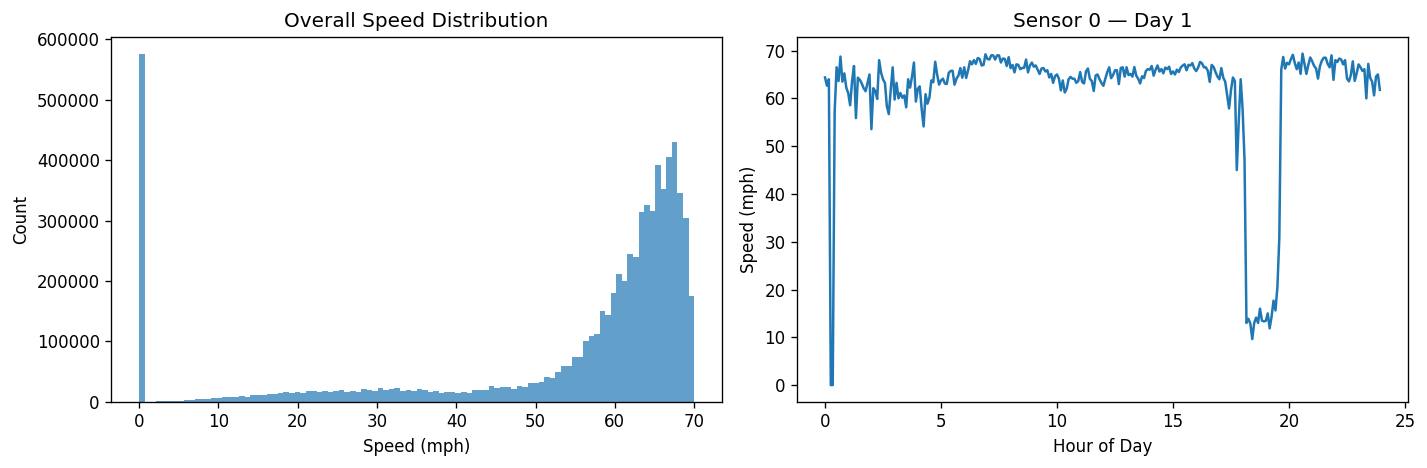

In [4]:
# Speed distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(speeds.flatten(), bins=100, edgecolor='none', alpha=0.7)
axes[0].set_xlabel('Speed (mph)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Speed Distribution')

# Daily pattern for a sample sensor
sensor_idx = 0
daily = speeds[:288, sensor_idx]  # first day
axes[1].plot(np.arange(288) * 5 / 60, daily)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Speed (mph)')
axes[1].set_title(f'Sensor {sensor_idx} — Day 1')
plt.tight_layout()
plt.show()

207 sensors


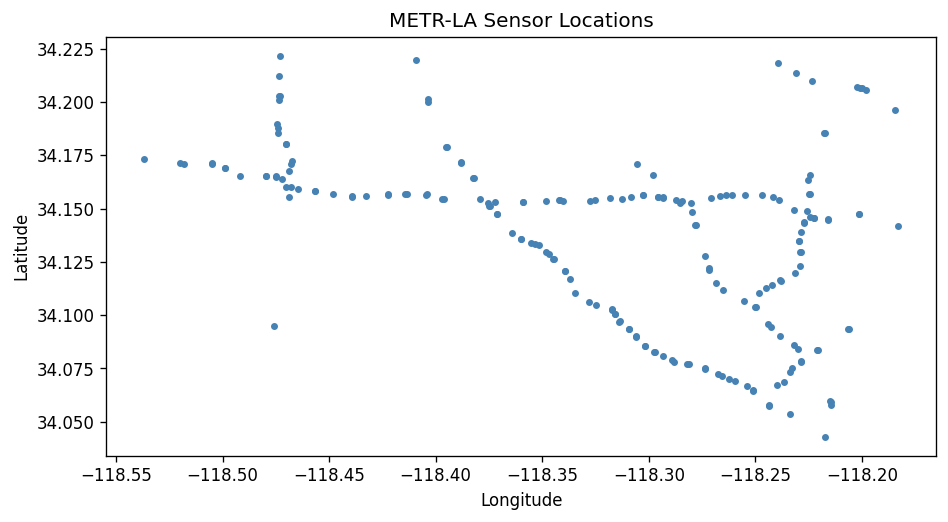

In [5]:
# Sensor locations
locs = pd.read_csv('../data/raw/graph_sensor_locations.csv')
print(f'{len(locs)} sensors')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(locs['longitude'], locs['latitude'], s=10, c='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('METR-LA Sensor Locations')
ax.ticklabel_format(useOffset=False)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Adjacency shape: (207, 207)
Total non-zero: 1722 (including 207 self-loops)

Off-diagonal edge weight distribution:
  Count: 1515
  Min:    0.1001
  25th:   0.1749
  Median: 0.3203
  75th:   0.5858
  Max:    0.9998


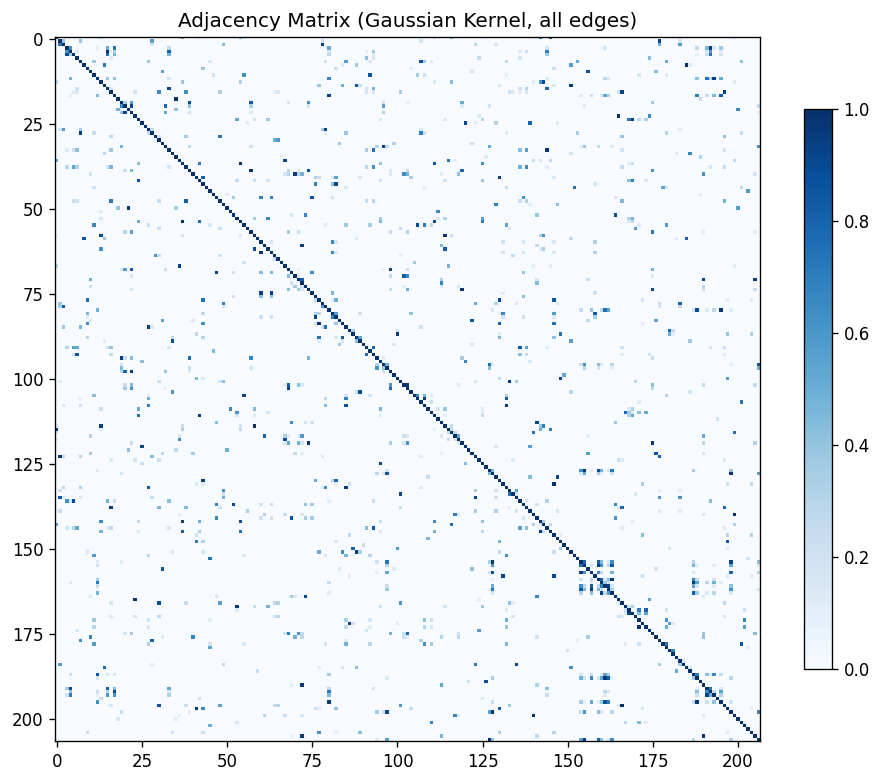

In [6]:
# Adjacency matrix — load from the original DCRNN precomputed pickle
import pickle

with open('../data/raw/adj_mx.pkl', 'rb') as f:
    pkl_data = pickle.load(f, encoding='latin1')

W_full = pkl_data[2]  # (207, 207) original adjacency matrix

print(f'Adjacency shape: {W_full.shape}')
print(f'Total non-zero: {(W_full > 0).sum()} (including {207} self-loops)')

# Edge weight distribution (off-diagonal only)
W_offdiag = W_full.copy()
np.fill_diagonal(W_offdiag, 0)
weights = W_offdiag[W_offdiag > 0]

print(f'\nOff-diagonal edge weight distribution:')
print(f'  Count: {len(weights)}')
print(f'  Min:    {weights.min():.4f}')
print(f'  25th:   {np.percentile(weights, 25):.4f}')
print(f'  Median: {np.percentile(weights, 50):.4f}')
print(f'  75th:   {np.percentile(weights, 75):.4f}')
print(f'  Max:    {weights.max():.4f}')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(W_full, cmap='Blues', aspect='equal')
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_title('Adjacency Matrix (Gaussian Kernel, all edges)')
plt.tight_layout()
plt.show()

 Epsilon  Off-Diagonal Edges  Avg Neighbors/Node  Graph Density (%)
     0.1                1515                 7.3               3.55
     0.2                1059                 5.1               2.48
     0.3                 791                 3.8               1.85
     0.4                 622                 3.0               1.46
     0.5                 469                 2.3               1.10
     0.6                 365                 1.8               0.86
     0.7                 255                 1.2               0.60


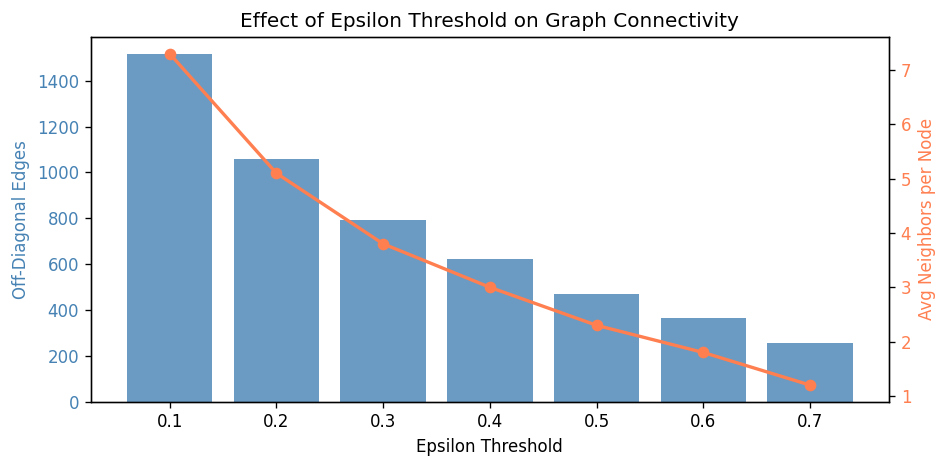


Exported to outputs/figures/epsilon_sensitivity.csv


In [7]:
# Epsilon threshold sensitivity analysis
# The epsilon parameter controls graph sparsity: edges with weight < epsilon are removed.
# Higher epsilon = sparser graph (only strong connections), lower = denser (more weak edges).

epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
rows_list = []

for eps in epsilons:
    kept = (weights >= eps).sum()
    avg_neighbors = kept / W_full.shape[0]
    density = kept / (W_full.shape[0] * (W_full.shape[0] - 1))  # exclude diagonal
    rows_list.append({
        'Epsilon': eps,
        'Off-Diagonal Edges': int(kept),
        'Avg Neighbors/Node': round(avg_neighbors, 1),
        'Graph Density (%)': round(density * 100, 2),
    })

epsilon_df = pd.DataFrame(rows_list)
print(epsilon_df.to_string(index=False))

# Visualization: edge count vs epsilon
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(epsilon_df['Epsilon'], epsilon_df['Off-Diagonal Edges'],
        width=0.08, color='steelblue', alpha=0.8)
ax1.set_xlabel('Epsilon Threshold')
ax1.set_ylabel('Off-Diagonal Edges', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(epsilon_df['Epsilon'], epsilon_df['Avg Neighbors/Node'],
         'o-', color='coral', linewidth=2)
ax2.set_ylabel('Avg Neighbors per Node', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.title('Effect of Epsilon Threshold on Graph Connectivity')
fig.tight_layout()
plt.show()

# Export for report
epsilon_df.to_csv('../outputs/figures/epsilon_sensitivity.csv', index=False)
print(f'\nExported to outputs/figures/epsilon_sensitivity.csv')